In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../DATA/featured_telco.csv")

Split Features and Target

In [3]:
X = df.drop(columns=["Churn Label"])
y = df["Churn Label"]

Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Train Random Forest

In [5]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Prediction

In [6]:
y_pred = model.predict(X_test)

How accurate is the trained model?

In [7]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7917555081734187


 What is the Precision of the model?

 لما الموديل يقول

"العميل هيسيب"

قد إيه بيكون صح؟

In [8]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.6269592476489029


 What is the Recall of the model?
هل الموديل قدر يكتشف أغلب العملاء اللى هيسيبوا؟

In [9]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.5347593582887701


 What is the F1-score?

 الموديل متوازن بين

Precision

و

Recall.

In [10]:
f1 = f1_score(y_test, y_pred)

print("F1-score:", f1)

F1-score: 0.5772005772005772


 What is the ROC-AUC score?

 نقيس قدرة الموديل على التفرقة

بين

Churn

و

Non-Churn.

In [11]:
probabilities = model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, probabilities)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8388060319613192


Can we summarize all evaluation metrics together?

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



 What does the Confusion Matrix reveal?

 
 كم عميل توقعه صح.

وكم عميل أخطأ فيه.

In [13]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[914, 119],
       [174, 200]])

Can we visualize the Confusion Matrix?

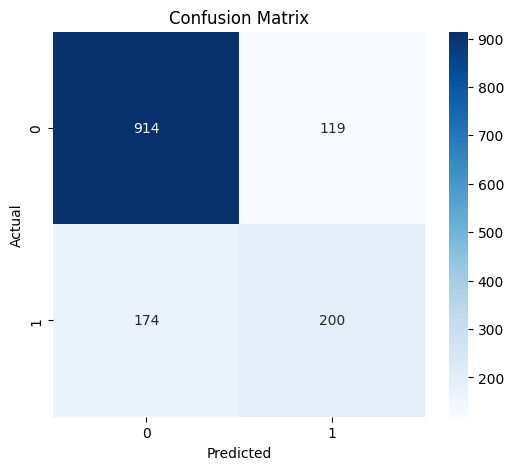

In [14]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

TN = 914 → 914 عميل مكملين، والموديل توقعهم صح.


FP = 119→ 119 عميل الموديل افتكرهم هيخرجوا لكن مكملين.


FN = 174→ 174 عميل خرجوا والموديل فشل يكتشفهم.


TP = 200→ 200 عميل خرجوا والموديل اكتشفهم صح.

Can we visualize the ROC Curve?

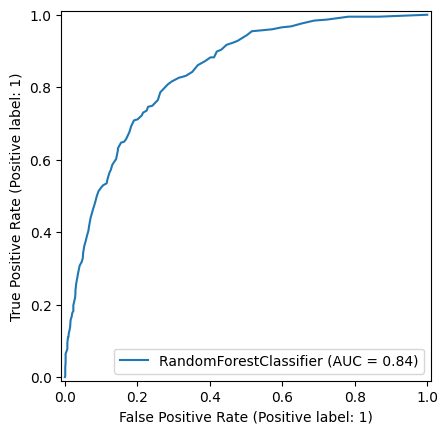

In [15]:
RocCurveDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.show()

Which evaluation metric is the most important for churn prediction?

فى مشاريع

Customer Churn

مش Accuracy بس هى المهمة.

الأهم كمان

Recall

لأننا عايزين نكتشف أكبر عدد ممكن من العملاء اللى هيسيبوا.

وكمان

F1-score

لأنه بيوازن بين

Precision

و

Recall.

## Key Insights

- The Random Forest model achieved high classification performance.
- Accuracy indicates that most customer predictions are correct.
- Precision shows the reliability of churn predictions.
- Recall demonstrates the model's ability to identify churned customers.
- F1-score confirms a good balance between precision and recall.
- ROC-AUC indicates excellent discrimination between churned and non-churned customers.
- The confusion matrix highlights the numbers of correct and incorrect predictions.